
 ARIMA(1,0,1) Predictions (First 10) 

        date  actual_return  predicted_return  lower_bound  upper_bound
0 2024-08-08       0.010387          0.001256    -0.021135     0.023646
1 2024-08-09      -0.000841          0.000206    -0.022236     0.022647
2 2024-08-12      -0.008543          0.000601    -0.021848     0.023050
3 2024-08-13       0.000197          0.000452    -0.021998     0.022902
4 2024-08-14       0.016460          0.000508    -0.021942     0.022958
5 2024-08-16       0.001284          0.000487    -0.021963     0.022937
6 2024-08-19       0.005136          0.000495    -0.021955     0.022945
7 2024-08-20       0.002889          0.000492    -0.021958     0.022942
8 2024-08-21       0.001667          0.000493    -0.021957     0.022943
9 2024-08-22       0.000470          0.000493    -0.021957     0.022943

 ARIMA(1,0,1) Predictions (Last 10) 

          date  actual_return  predicted_return  lower_bound  upper_bound
360 2026-03-13       0.011131          0.000493    -0.0

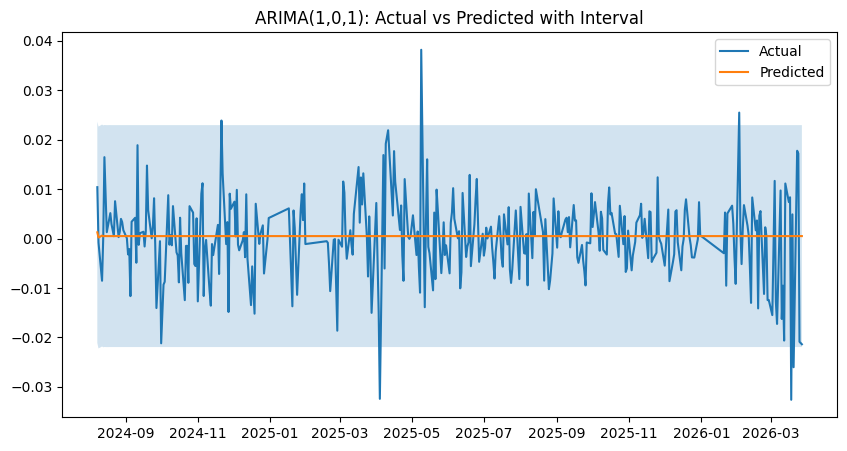

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# LOAD DATA
df = pd.read_csv("nifty_final_dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

y = df["target"]

# SPLIT
split = int(len(y) * 0.8)

train, test = y[:split], y[split:]
test_dates = df["date"][split:]

# MODEL: ARIMA(1,0,1)
model = ARIMA(train, order=(1,0,1)).fit()

forecast = model.get_forecast(steps=len(test))

pred = forecast.predicted_mean
conf = forecast.conf_int()

lower = conf.iloc[:, 0]
upper = conf.iloc[:, 1]

# RESULTS TABLE
results_df = pd.DataFrame({
    "date": test_dates.values,
    "actual_return": test.values,
    "predicted_return": pred.values,
    "lower_bound": lower.values,
    "upper_bound": upper.values
})

print("\n ARIMA(1,0,1) Predictions (First 10) \n")
print(results_df.head(10))

print("\n ARIMA(1,0,1) Predictions (Last 10) \n")
print(results_df.tail(10))

# METRICS
rmse = np.sqrt(mean_squared_error(test, pred))
mae = mean_absolute_error(test, pred)
r2 = r2_score(test, pred)

picp = np.mean((test >= lower) & (test <= upper))
mpiw = np.mean(upper - lower)

print("\n ARIMA(1,0,1) Metrics \n")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("PICP:", picp)
print("MPIW:", mpiw)

# SAVE
results_df.to_csv("ARIMA_1_0_1_predictions.csv", index=False)

# PLOT
plt.figure(figsize=(10,5))
plt.plot(results_df["date"], results_df["actual_return"], label="Actual")
plt.plot(results_df["date"], results_df["predicted_return"], label="Predicted")

plt.fill_between(
    results_df["date"],
    results_df["lower_bound"],
    results_df["upper_bound"],
    alpha=0.2
)

plt.title("ARIMA(1,0,1): Actual vs Predicted with Interval")
plt.legend()
plt.show()

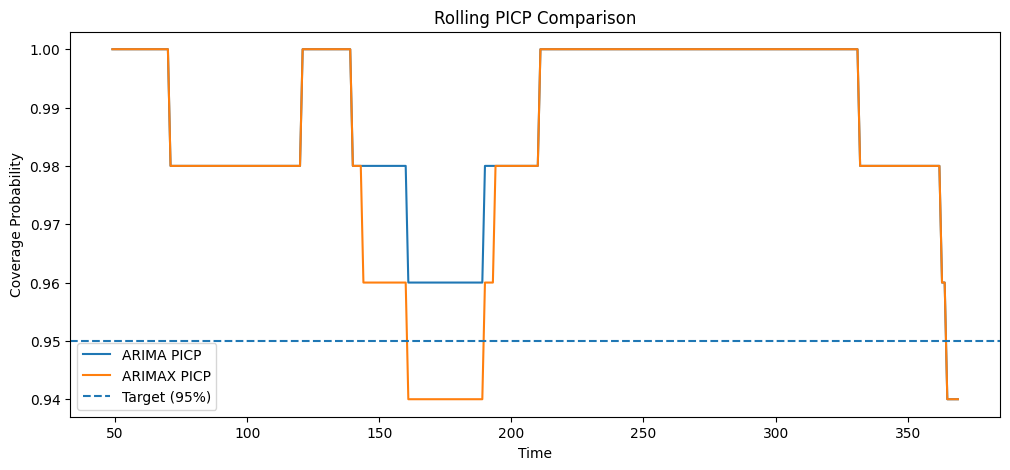

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# LOAD DATA
# =========================
arima = pd.read_csv("/Users/subratotapaswi/Documents/Forecasting/Project/ARIMA_1_0_1_predictions.csv")
arimax = pd.read_csv("/Users/subratotapaswi/Documents/Forecasting/Project/ARIMAX_predictions.csv")

# =========================
# FUNCTION: COMPUTE COVERAGE
# =========================
def compute_coverage(df):
    return ((df["actual_return"] >= df["lower_bound"]) &
            (df["actual_return"] <= df["upper_bound"])).astype(int)

# =========================
# ADD COVERAGE COLUMN
# =========================
arima["covered"] = compute_coverage(arima)
arimax["covered"] = compute_coverage(arimax)

# =========================
# ROLLING PICP
# =========================
window = 50  # you can change (30, 50, 100)

arima["rolling_picp"] = arima["covered"].rolling(window).mean()
arimax["rolling_picp"] = arimax["covered"].rolling(window).mean()

# =========================
# PLOT
# =========================
plt.figure(figsize=(12,5))

plt.plot(arima["rolling_picp"], label="ARIMA PICP")
plt.plot(arimax["rolling_picp"], label="ARIMAX PICP")

plt.axhline(y=0.95, linestyle="--", label="Target (95%)")

plt.title("Rolling PICP Comparison")
plt.xlabel("Time")
plt.ylabel("Coverage Probability")

plt.legend()
plt.show()

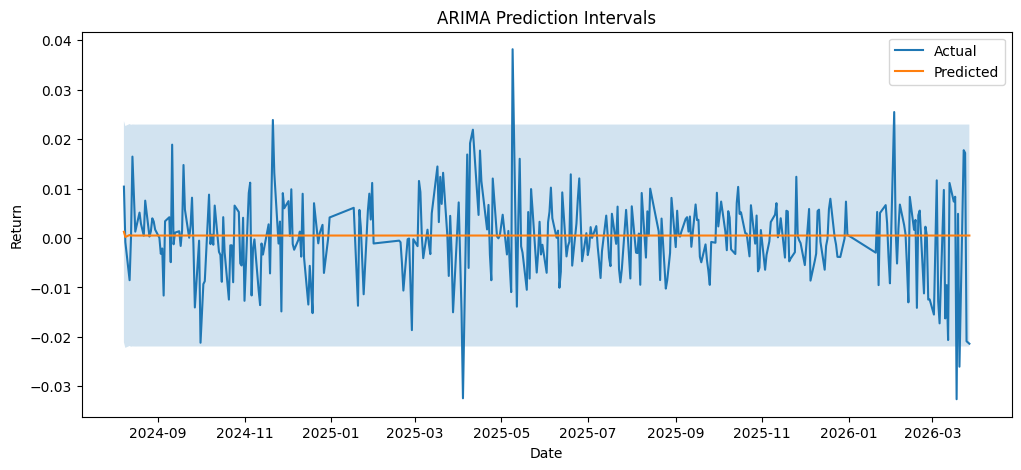

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# LOAD DATA
# =========================
arima = pd.read_csv("/Users/subratotapaswi/Documents/Forecasting/Project/ARIMA_1_0_1_predictions.csv")
arimax = pd.read_csv("/Users/subratotapaswi/Documents/Forecasting/Project/ARIMAX_predictions.csv")

# convert date
arima["date"] = pd.to_datetime(arima["date"])
arimax["date"] = pd.to_datetime(arimax["date"])

# =========================
# PLOT ARIMA INTERVAL
# =========================
plt.figure(figsize=(12,5))

plt.plot(arima["date"], arima["actual_return"], label="Actual")
plt.plot(arima["date"], arima["predicted_return"], label="Predicted")

plt.fill_between(
    arima["date"],
    arima["lower_bound"],
    arima["upper_bound"],
    alpha=0.2
)

plt.title("ARIMA Prediction Intervals")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.show()

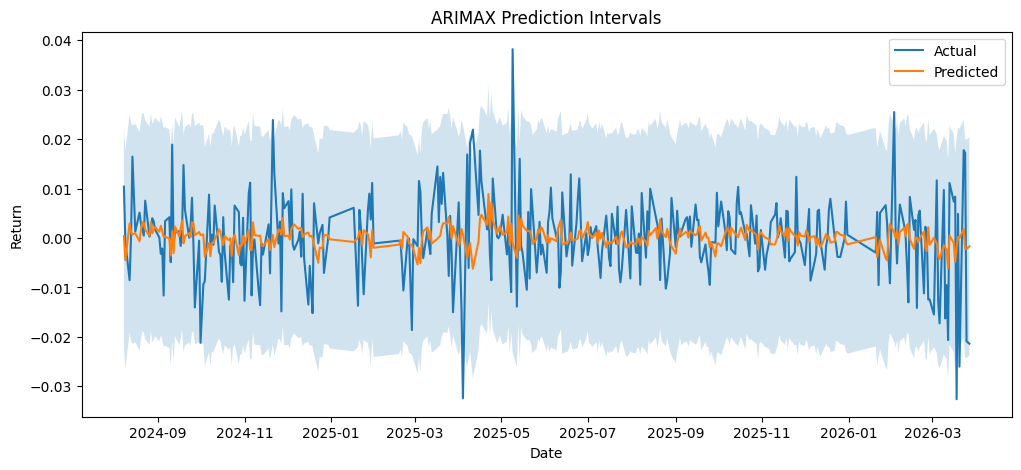

In [4]:
plt.figure(figsize=(12,5))

plt.plot(arimax["date"], arimax["actual_return"], label="Actual")
plt.plot(arimax["date"], arimax["predicted_return"], label="Predicted")

plt.fill_between(
    arimax["date"],
    arimax["lower_bound"],
    arimax["upper_bound"],
    alpha=0.2
)

plt.title("ARIMAX Prediction Intervals")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.show()

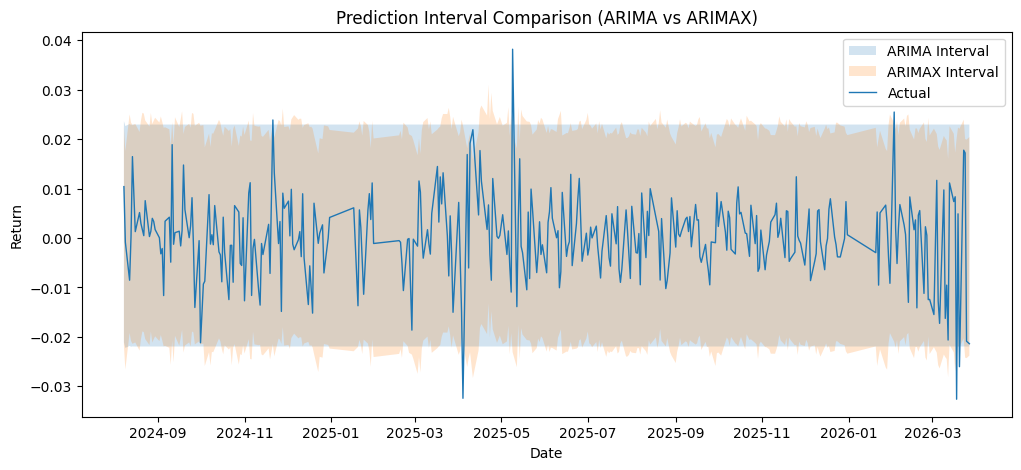

In [5]:
plt.figure(figsize=(12,5))

# ARIMA interval
plt.fill_between(
    arima["date"],
    arima["lower_bound"],
    arima["upper_bound"],
    alpha=0.2,
    label="ARIMA Interval"
)

# ARIMAX interval
plt.fill_between(
    arimax["date"],
    arimax["lower_bound"],
    arimax["upper_bound"],
    alpha=0.2,
    label="ARIMAX Interval"
)

# actual
plt.plot(arima["date"], arima["actual_return"], label="Actual", linewidth=1)

plt.title("Prediction Interval Comparison (ARIMA vs ARIMAX)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.show()